In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
device = torch.device('cuda' if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [6]:
dataset = open('/kaggle/input/tiny-shakespeare/tiny-shakespeare.txt').read()

In [7]:
len(dataset) #1 million

1115394

In [8]:
vocab = sorted(list(set(dataset)))

stoi = {s:i for i,s in enumerate(vocab)}
itos = {i:s for i,s in enumerate(vocab)}
vocab_size = len(vocab)

In [9]:
#encode and decode function
encode = lambda x: [stoi[c] for c in x]
decode = lambda l: "".join([itos[i] for i in l])

In [10]:
data = torch.tensor(encode(dataset),dtype=torch.int64)

In [11]:
n = int(0.9 * len(dataset))

train = data[:n]
val = data[n:]

In [12]:
context_size = 10
batch_size= 512

In [13]:
def build_dataset(split):
    data = train if split=='train' else val
    X = []
    Y = []
    for i in range(len(data)- context_size):
        X.append(data[i : i+context_size])
        Y.append(data[i+1 : i+context_size+1])
    X = torch.stack(X)
    Y = torch.stack(Y)
    return X,Y

In [14]:
X_train,Y_train = build_dataset('train')

In [15]:
x_train, y_train = X_train.to(device), Y_train.to(device)

In [16]:
class RNN(nn.Module):
    def __init__(self, n_dim, n_hidden, gain=5/3):
        super().__init__()
        self.n_dim = n_dim
        self.n_hidden = n_hidden
        self.gain = 5/3
        self.embedding = nn.Embedding(vocab_size,n_dim)

        self.Wxh = nn.Parameter(torch.randn(n_dim, n_hidden) * gain * (6/(n_dim + n_hidden))**0.5)      
        self.Whh = nn.Parameter(torch.randn(n_hidden,n_hidden) * gain * (6/(n_hidden + n_hidden))**0.5 )
        self.Who = nn.Parameter(torch.randn(n_hidden, vocab_size) *0.01)

        self.bh = nn.Parameter(torch.zeros(n_hidden))
        self.bo = nn.Parameter(torch.zeros(vocab_size))


    def forward(self,x, h=None):
        logits = []
        batch, steps = x.size()
        if h is None:
            h = torch.zeros(batch, self.n_hidden).to(device)  
        emb = self.embedding(x)
        
        for i in range(steps):
            xin = emb[:,i,:]
            h = torch.tanh(xin @ self.Wxh + h @ self.Whh + self.bh)

            out = h @ self.Who + self.bo
            logits.append(out)

        logits = torch.stack(logits, dim=1)
        return logits, h

        
    

In [26]:
1e-5 + 1e-4 * 1961

0.19611

In [95]:
# xb,yb = build_dataset('train')
# logits,h = rnn(xb) #logits for timestep 1 next char is predicted

# #first char is input to model for 4 exmaples.
# #The model predicts the next char for input i.2 2nd character is predicted
# #the actual second character is Yb[0]

# print(out.shape,yb.shape)
# counts = out.exp()
# probs = counts / counts.sum(1,keepdim=True)
# logprobs = probs.log()
# target = yb[:,0]

# loss = -logprobs[range(0,4), target].sum() / batch_size
# loss

In [30]:
#Finding a good learning rate

from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(x_train, y_train)
dataloader = DataLoader(dataset, batch_size = batch_size, shuffle=True)

lr = 1e-5
model = RNN(10,100).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr = lr)
criterion = nn.CrossEntropyLoss()

dataset = TensorDataset(x_train, y_train)
dataloader = DataLoader(dataset, batch_size = batch_size, shuffle=True)
lri = []
lossi = []

for x_batch, y_batch in dataloader:
    optimizer.param_groups[0]['lr'] = lr
    logits, h = model(x_batch)

    loss = criterion(logits[:,-1,:],y_batch[:,-1])
    optimizer.zero_grad()
    loss.backward()

    #print(f'learning rate = {lr:.6f}\t loss = {loss.item()}')
    
    lri.append(lr)
    lossi.append(loss.item())   
    #update
    optimizer.step()
    lr += 1e-4
    
    

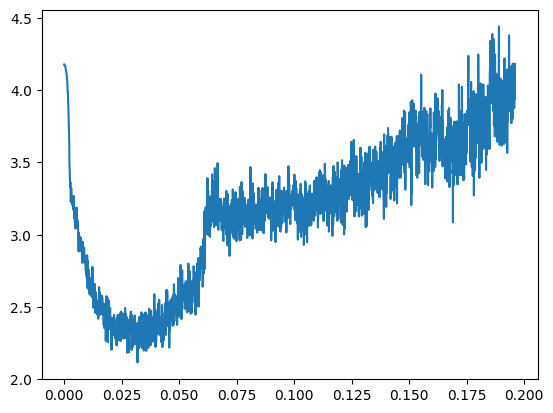

In [31]:
import matplotlib.pyplot as plt
plt.plot(lri, lossi)

In [39]:
from torch.utils.data import TensorDataset, DataLoader

learning_rate = 0.00325 
epochs = 30

model = RNN(10,100).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)
criterion = nn.CrossEntropyLoss()

dataset = TensorDataset(x_train,y_train)
dataloader = DataLoader(dataset = dataset, batch_size = batch_size, shuffle=True)

losses = []
for epoch in range(epochs):
    epoch_loss = 0
    for x_batch,y_batch in dataloader: 
        logits ,h = model(x_batch)
        loss = criterion(logits.view(-1,65), y_batch.view(-1))
    
        #reset the gradient
        optimizer.zero_grad()
        loss.backward()
    
        losses.append(loss.item())
        #update the gradien
        optimizer.step()
        epoch_loss += loss.item()

    epoch_loss/= len(dataloader)
    if epoch % 5 == 0:
        print(f'{epoch}/{epochs}\t loss={epoch_loss:.4f}')    
    #break

0/30	 loss=2.0406
5/30	 loss=1.7852
10/30	 loss=1.7698
15/30	 loss=1.7629
20/30	 loss=1.7595
25/30	 loss=1.7574


In [102]:
#training with learning rate decay
# import time

# learning_rate = 0.001
# epochs = 50000
# #model = RNN(10,100).to(device)
# optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)
# #criterion = nn.CrossEntropyLoss()
# start = time.time()
# for epoch in range(epochs):

#     xb,yb = build_dataset('train')
#     x_batch, y_batch = xb.to(device),yb.to(device)
#     logits ,h = model(x_batch)
#     loss = criterion(logits.view(-1,65), y_batch.view(-1))

#     #reset the gradient
#     optimizer.zero_grad()
#     loss.backward()

#     losses.append(loss.item())
#     #update the gradien
#     optimizer.step()
    
#     if epoch % 10000 == 0:
#         print(f'{epoch}/{epochs}\t loss={loss.item():.4f}')    

# if device == 'cuda':
#     torch.cuda.synchronize()
# end = time.time()


# print(f'The time taken is {end-start}:.2f on {device}')
    
    
    

0/50000	 loss=2.6621
10000/50000	 loss=2.9067
20000/50000	 loss=2.2492
30000/50000	 loss=2.4830
40000/50000	 loss=2.4175
The time taken is 255.44812035560608:.2f on cpu


learning rate decay + Xavier init 

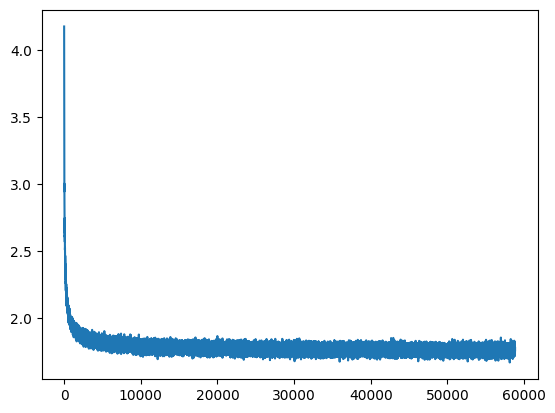

In [40]:
import matplotlib.pyplot as plt
plt.plot(losses)

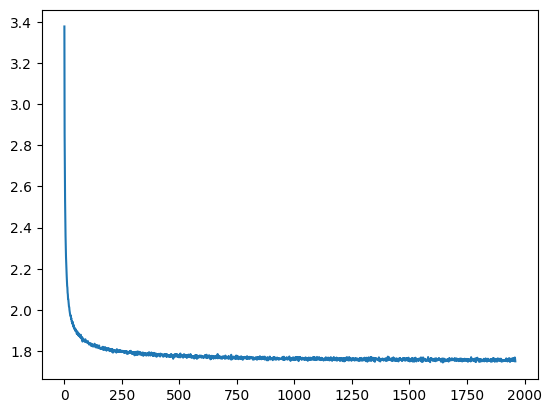

In [41]:
new_loss = torch.tensor(losses).view(1961,-1).mean(1,keepdim=False)
plt.plot(new_loss)

In [35]:
# model.load_state_dict(torch.load('/kaggle/input/rnn-torch-weight/rnn_wieght_torch.pth', map_location=torch.device('cpu')))

<All keys matched successfully>

# 

In [42]:
with torch.no_grad():
    def get_loss(split):
        n_hidden = 100
        ix = torch.randint(0, len(train) - context_size,(batch_size,))
        x_batch = torch.stack([X_train[i] for i in ix])
        y_batch = torch.stack([Y_train[i] for i in ix])
        xb = x_batch.to(device)
        yb = y_batch.to(device)
        logits,h = model(xb)
        criterion = nn.CrossEntropyLoss()
        loss = criterion( logits.view(-1,65),yb.view(-1))
        
        print(f'{split} loss ={loss.item()}')

    get_loss('train')
    get_loss('val')

train loss =1.7322273254394531
val loss =1.7362613677978516


with nothing* 
    train - 2.1
    val - 2.5

with batch_size : 32<br>
train = 2.20
val = 2.03

with batch_size : 256<br>
epochs = 50
train : 1.997
val : 1.95919
the loss plot looks weird. Need to check it out tomorrow.

batch size 256
with epochs=30
trai : 1.9209
val : 2.0179

bacth size 256
epochs = 30
with lr = 0.001
train 1.70
val 1.73

batch size 512 lr  = 0.001
epochs = 30
train : 1.66
test : 1.75

batch size 512 lr = 0.00325
epochs = 30
train loss =1.7322273254394531
val loss =1.7362613677978516


In [43]:
torch.save(model.state_dict(),'rnn_wieght_torch.pth')

In [44]:
#sampling:
def predict_next_chars(word, num_of_chars = 10):
    tokenized = torch.tensor(encode(word))
    step = tokenized.size()
    input_tensor = tokenized.view(1,-1).to(device)
    
    logits, h = model(input_tensor)
    
    def predict(word, logits, h):
        prediction = []
        for i in range(num_of_chars):
            logit = logits[:,-1,:]
            probs = F.softmax(logit, dim=1)
            next_char = torch.multinomial(probs, num_samples=1)
            prediction.append(itos[next_char.item()])
            logits ,h = model(next_char.view(1,-1), h)
        return {'prediciton ': "".join(prediction), 'full' : "".join(list(word) + prediction)}
        
    return predict(word,logits, h)

In [45]:
predict_next_chars('he shall')

{'prediciton ': ' noble abb', 'full': 'he shall noble abb'}